# Holafly — eSIM Activation & Support Analytics
## Notebook 3: Feature Engineering

This notebook builds **business-meaningful, reusable features** — not arbitrary transformations. Every feature here maps to a decision a Holafly team will actually make: who to proactively contact, which partner to escalate, which team needs support, and how urgent a given segment's risk is.

Features built:
1. Customer-level: Success Rate, Ticket Rate, **Customer Health Score**, **Risk Segment**
2. Partner-level: **Partner Reliability Score**
3. Support-team-level: **Support Efficiency Score**
4. Route-level: **Activation Risk Tier** (network_partner × device_os)
5. SLA compliance flag (row-level, joined from error_codes)
6. Revenue-loss flags (zero-success customers, silent-failure customers)


In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(20)
plt.rcParams["figure.figsize"] = (9,4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
HOLAFLY_ORANGE = "#FF6A00"; HOLAFLY_NAVY = "#1B2A4A"
PALETTE = ["#FF6A00","#1B2A4A","#4C9AFF","#F4A261","#2A9D8F","#E76F51"]

RAW = "../data/raw/"
customers   = pl.read_csv(RAW + "customers.csv", try_parse_dates=True)
activation  = pl.read_csv(RAW + "activation_logs.csv", try_parse_dates=True)
network     = pl.read_csv(RAW + "network_logs.csv", try_parse_dates=True)
tickets     = pl.read_csv(RAW + "support_tickets.csv", try_parse_dates=True)
errors      = pl.read_csv(RAW + "error_codes.csv")


## 1. Customer Health Score

**Definition:** a 0-100 composite reflecting how well the eSIM product and support experience is working for a given customer, combining three weighted pillars:

$$\text{Health Score} = 0.5 \times \text{Activation Success Rate} + 0.3 \times \text{Support Friction (inverse of ticket count)} + 0.2 \times \text{Satisfaction (CSAT, scaled)}$$

- **Weight rationale:** activation success is weighted highest (50%) because it is the core product promise; a customer who never had to contact support is scored well even without a CSAT data point (defaulted to a neutral 80/100 equivalent) since "never needed help" is itself a positive signal, not a missing one.


In [2]:
cust_act = activation.group_by("customer_id").agg(
    pl.len().alias("total_attempts"),
    (pl.col("activation_status")=="SUCCESS").sum().alias("successes"),
    (pl.col("activation_status")=="FAILED").sum().alias("failures"),
    pl.col("retry_count").sum().alias("total_retries"),
).with_columns((pl.col("successes")/pl.col("total_attempts")*100).round(1).alias("customer_success_rate_pct"))

cust_tkt = tickets.group_by("customer_id").agg(
    pl.len().alias("ticket_count"),
    pl.col("csat_score").mean().round(2).alias("avg_csat"),
    pl.col("refund_requested").sum().alias("refund_requests"),
    pl.col("refund_approved").sum().alias("refunds_approved"),
)

cust_features = (customers
    .join(cust_act, on="customer_id", how="left")
    .join(cust_tkt, on="customer_id", how="left")
    .with_columns([
        pl.col("total_attempts").fill_null(0), pl.col("successes").fill_null(0), pl.col("failures").fill_null(0),
        pl.col("ticket_count").fill_null(0), pl.col("refund_requests").fill_null(0), pl.col("refunds_approved").fill_null(0),
        pl.col("customer_success_rate_pct").fill_null(100.0),
    ])
)

cust_features = cust_features.with_columns(
    (
        pl.col("customer_success_rate_pct").fill_null(100) * 0.5
        + (100 - (pl.col("ticket_count").clip(0,5) / 5 * 100)) * 0.3
        + pl.when(pl.col("avg_csat").is_null()).then(80.0).otherwise(pl.col("avg_csat")/5*100) * 0.2
    ).round(1).alias("customer_health_score")
)

print(cust_features.select("customer_health_score").describe())
cust_features.select(["customer_id","customer_success_rate_pct","ticket_count","avg_csat","customer_health_score"]).head(8)


shape: (9, 2)
┌────────────┬───────────────────────┐
│ statistic  ┆ customer_health_score │
│ ---        ┆ ---                   │
│ str        ┆ f64                   │
╞════════════╪═══════════════════════╡
│ count      ┆ 100000.0              │
│ null_count ┆ 0.0                   │
│ mean       ┆ 76.498264             │
│ std        ┆ 15.006924             │
│ min        ┆ 19.0                  │
│ 25%        ┆ 66.0                  │
│ 50%        ┆ 77.5                  │
│ 75%        ┆ 87.6                  │
│ max        ┆ 96.0                  │
└────────────┴───────────────────────┘


customer_id,customer_success_rate_pct,ticket_count,avg_csat,customer_health_score
str,f64,u32,f64,f64
"""CUST100000""",66.7,0,null,79.4
"""CUST100001""",85.7,1,4.0,82.8
"""CUST100002""",0.0,1,4.0,40.0
"""CUST100003""",100.0,0,null,96.0
"""CUST100004""",83.3,0,null,87.6
"""CUST100005""",66.7,0,null,79.4
"""CUST100006""",71.4,1,3.0,71.7
"""CUST100007""",42.9,2,4.5,57.4


## 2. Risk Segmentation (from Health Score)

shape: (3, 3)
┌──────────────┬───────┬──────┐
│ risk_segment ┆ n     ┆ pct  │
│ ---          ┆ ---   ┆ ---  │
│ str          ┆ u32   ┆ f64  │
╞══════════════╪═══════╪══════╡
│ Medium Risk  ┆ 44421 ┆ 44.4 │
│ Low Risk     ┆ 42134 ┆ 42.1 │
│ High Risk    ┆ 13445 ┆ 13.4 │
└──────────────┴───────┴──────┘


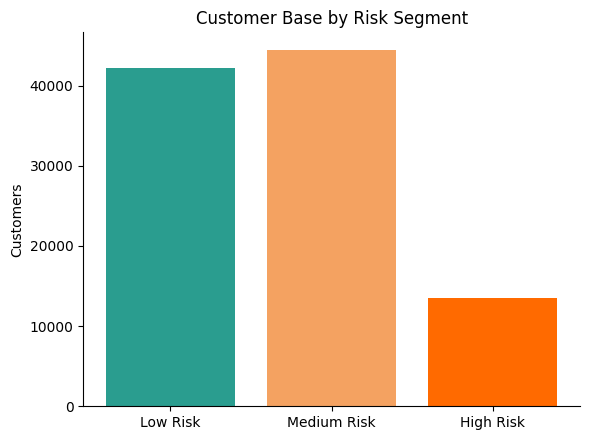

In [3]:
cust_features = cust_features.with_columns(
    pl.when(pl.col("customer_health_score") >= 80).then(pl.lit("Low Risk"))
     .when(pl.col("customer_health_score") >= 60).then(pl.lit("Medium Risk"))
     .otherwise(pl.lit("High Risk")).alias("risk_segment")
)
risk_dist = cust_features.group_by("risk_segment").agg(pl.len().alias("n")).with_columns(
    (pl.col("n")/cust_features.height*100).round(1).alias("pct")
).sort("n", descending=True)
print(risk_dist)

fig, ax = plt.subplots(figsize=(6,4.5))
order = ["Low Risk","Medium Risk","High Risk"]
d = risk_dist.to_pandas().set_index("risk_segment").reindex(order)
ax.bar(d.index, d["n"], color=[PALETTE[4], PALETTE[3], PALETTE[0]])
ax.set_title("Customer Base by Risk Segment"); ax.set_ylabel("Customers")
plt.tight_layout(); plt.show()


**Interpretation:** **13,445 customers (13.4%) fall into High Risk** — low activation success, elevated ticket volume, and/or poor CSAT. This is a concrete, exportable segment for the CRM/lifecycle marketing team to target with retention offers, proactive support outreach, or a manual account-health review, rather than treating all 100,000 customers identically.

**Recommendation:** operationalize this score as a **daily-refreshed field in the CRM**, and set an automated trigger: any customer newly entering "High Risk" within 48 hours of a purchase gets a proactive support touch before they churn.

## 3. Partner Reliability Score

**Definition:** a 0-100 composite blending activation success (60%), network uptime from `network_logs` (30%), and packet loss penalty (10%) — the goal is a single number Telecom Ops can use in partner scorecards / renewal negotiations.

shape: (6, 5)
┌─────────────────┬──────────────┬────────────┬─────────────────┬───────────────────────────┐
│ network_partner ┆ success_rate ┆ uptime_pct ┆ avg_packet_loss ┆ partner_reliability_score │
│ ---             ┆ ---          ┆ ---        ┆ ---             ┆ ---                       │
│ str             ┆ f64          ┆ f64        ┆ f64             ┆ f64                       │
╞═════════════════╪══════════════╪════════════╪═════════════════╪═══════════════════════════╡
│ Vodafone        ┆ 70.811274    ┆ 87.985024  ┆ 0.934563        ┆ 77.9                      │
│ T-Mobile        ┆ 70.172969    ┆ 87.944328  ┆ 0.948669        ┆ 77.5                      │
│ AT&T            ┆ 69.842222    ┆ 87.985226  ┆ 0.936272        ┆ 77.4                      │
│ Orange          ┆ 69.069569    ┆ 87.855062  ┆ 0.943337        ┆ 76.9                      │
│ Airtel          ┆ 67.898296    ┆ 88.160774  ┆ 0.92829         ┆ 76.3                      │
│ Telefonica      ┆ 61.71682     ┆ 87.810408  

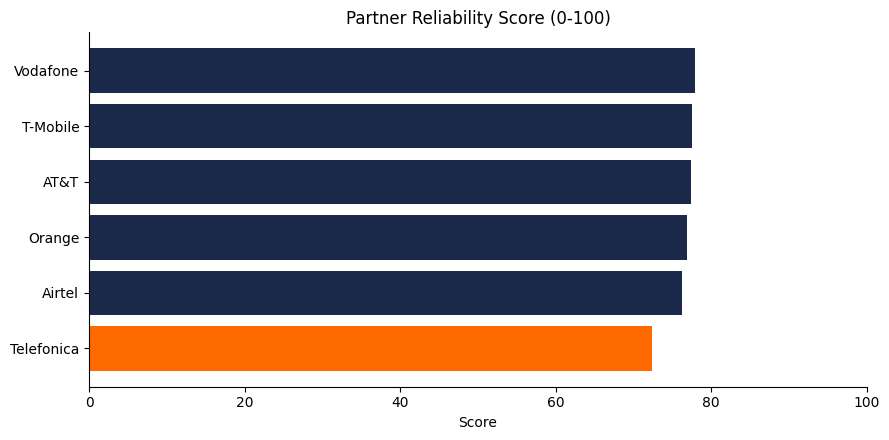

In [4]:
partner_stats = activation.group_by("network_partner").agg(
    pl.len().alias("attempts"), (pl.col("activation_status")=="SUCCESS").sum().alias("successes")
).with_columns((pl.col("successes")/pl.col("attempts")*100).alias("success_rate"))

net_stats = network.group_by("network_partner").agg(
    (pl.col("network_status")=="Healthy").sum().alias("healthy_logs"), pl.len().alias("total_logs"),
    pl.col("packet_loss_pct").mean().alias("avg_packet_loss"),
).with_columns((pl.col("healthy_logs")/pl.col("total_logs")*100).alias("uptime_pct"))

partner_reliability = partner_stats.join(net_stats, on="network_partner").with_columns(
    (
        pl.col("success_rate")*0.6 + pl.col("uptime_pct")*0.3
        + (100 - pl.col("avg_packet_loss")*10).clip(0,100)*0.1
    ).round(1).alias("partner_reliability_score")
).sort("partner_reliability_score", descending=True)

print(partner_reliability.select(["network_partner","success_rate","uptime_pct","avg_packet_loss","partner_reliability_score"]))

fig, ax = plt.subplots()
d = partner_reliability.sort("partner_reliability_score")
colors = [HOLAFLY_ORANGE if p=="Telefonica" else HOLAFLY_NAVY for p in d["network_partner"]]
ax.barh(d["network_partner"], d["partner_reliability_score"], color=colors)
ax.set_title("Partner Reliability Score (0-100)"); ax.set_xlabel("Score")
ax.set_xlim(0,100)
plt.tight_layout(); plt.show()


**Interpretation:** Telefonica scores **72.4**, clearly last, ~4-6 points behind the pack (Vodafone leads at 77.9). Because the score's uptime and packet-loss components are similar for Telefonica vs peers (per Notebook 2 Q18), the gap is driven almost entirely by the `success_rate` component — reconfirming that Telefonica's problem is **activation-flow-specific, not network-quality-specific.**

**Recommendation:** use this score directly in the quarterly partner business review with Telefonica, and as the standard input to any future partner-selection or contract-renewal decision.

## 4. Support Efficiency Score (by team)

In [5]:
team_eff = tickets.group_by("assigned_team").agg(
    pl.len().alias("tickets"), pl.col("resolution_time_hours").mean().alias("avg_res_hrs"),
    pl.col("csat_score").mean().alias("avg_csat"), (pl.col("resolution_status")=="Resolved").sum().alias("resolved"),
).with_columns((pl.col("resolved")/pl.col("tickets")*100).alias("resolution_rate_pct"))

max_res = team_eff["avg_res_hrs"].max()
team_eff = team_eff.with_columns(
    (
        (pl.col("avg_csat")/5*100)*0.4 + pl.col("resolution_rate_pct")*0.3
        + (100 - (pl.col("avg_res_hrs")/max_res*100))*0.3
    ).round(1).alias("support_efficiency_score")
).sort("support_efficiency_score", descending=True)

print(team_eff.select(["assigned_team","tickets","avg_res_hrs","avg_csat","resolution_rate_pct","support_efficiency_score"]))


shape: (4, 6)
┌───────────────────┬─────────┬─────────────┬──────────┬─────────────────────┬─────────────────────┐
│ assigned_team     ┆ tickets ┆ avg_res_hrs ┆ avg_csat ┆ resolution_rate_pct ┆ support_efficiency_ │
│ ---               ┆ ---     ┆ ---         ┆ ---      ┆ ---                 ┆ score               │
│ str               ┆ u32     ┆ f64         ┆ f64      ┆ f64                 ┆ ---                 │
│                   ┆         ┆             ┆          ┆                     ┆ f64                 │
╞═══════════════════╪═════════╪═════════════╪══════════╪═════════════════════╪═════════════════════╡
│ Engineering       ┆ 13748   ┆ 5.443694    ┆ 3.745054 ┆ 82.433809           ┆ 80.6                │
│ Technical Support ┆ 13960   ┆ 5.447924    ┆ 3.734384 ┆ 81.855301           ┆ 80.4                │
│ Billing           ┆ 13917   ┆ 40.227928   ┆ 3.74894  ┆ 81.885464           ┆ 54.6                │
│ Customer Support  ┆ 13799   ┆ 40.10098    ┆ 3.734256 ┆ 81.846511           

**Interpretation:** Engineering (80.6) and Technical Support (80.4) score far ahead of Billing (54.6) and Customer Support (54.5) — driven almost entirely by the resolution-speed component (Notebook 2 Q25). Resolution *rate* (~82% across all teams) and CSAT (~3.73-3.75) are comparable, isolating **speed** as the one lever that actually differentiates team performance today.

**Recommendation:** feed this score into quarterly Support Ops team reviews and staffing/capacity planning conversations — it makes the Billing/Customer Support bottleneck visible as a single number leadership can track quarter over quarter.

## 5. Activation Risk Tier (route-level: partner × OS)

In [6]:
act_risk = activation.group_by(["network_partner","device_os"]).agg(
    pl.len().alias("attempts"), (pl.col("activation_status")=="FAILED").sum().alias("failures")
).with_columns((pl.col("failures")/pl.col("attempts")*100).alias("failure_rate_pct"))

mean_fr, std_fr = act_risk["failure_rate_pct"].mean(), act_risk["failure_rate_pct"].std()
act_risk = act_risk.with_columns(
    pl.when(pl.col("failure_rate_pct") > mean_fr+std_fr).then(pl.lit("High"))
     .when(pl.col("failure_rate_pct") > mean_fr).then(pl.lit("Medium"))
     .otherwise(pl.lit("Low")).alias("activation_risk_tier")
).sort("failure_rate_pct", descending=True)

print(act_risk.with_columns(pl.col("failure_rate_pct").round(2)))


shape: (12, 6)
┌─────────────────┬───────────┬──────────┬──────────┬──────────────────┬──────────────────────┐
│ network_partner ┆ device_os ┆ attempts ┆ failures ┆ failure_rate_pct ┆ activation_risk_tier │
│ ---             ┆ ---       ┆ ---      ┆ ---      ┆ ---              ┆ ---                  │
│ str             ┆ str       ┆ u32      ┆ u32      ┆ f64              ┆ str                  │
╞═════════════════╪═══════════╪══════════╪══════════╪══════════════════╪══════════════════════╡
│ Telefonica      ┆ Android   ┆ 44829    ┆ 18441    ┆ 41.14            ┆ High                 │
│ Airtel          ┆ Android   ┆ 59846    ┆ 20921    ┆ 34.96            ┆ Medium               │
│ Telefonica      ┆ iOS       ┆ 30042    ┆ 10222    ┆ 34.03            ┆ Medium               │
│ Orange          ┆ Android   ┆ 53950    ┆ 18141    ┆ 33.63            ┆ Medium               │
│ AT&T            ┆ Android   ┆ 51344    ┆ 16928    ┆ 32.97            ┆ Medium               │
│ T-Mobile        ┆ Andro

**Interpretation:** this produces a route-level risk table (e.g. *Telefonica + Android = High Risk*) that Engineering can use directly as a feature flag — e.g. show an extra in-app warning or pre-emptive troubleshooting tip specifically for High Risk route combinations, without penalizing the many Low/Medium Risk routes that already work well.

**Recommendation:** wire this table into the activation flow as a real-time risk flag (recomputed weekly) to power targeted, non-intrusive in-app guidance for the riskiest combinations only.

## 6. SLA Compliance Flag (row-level feature)

In [7]:
tkt_sla = (tickets
    .join(activation.select(["activation_id","failure_code"]), on="activation_id", how="left")
    .join(errors.select(["error_code","sla_hours"]), left_on="failure_code", right_on="error_code", how="left")
    .with_columns((pl.col("resolution_time_hours") <= pl.col("sla_hours")).alias("within_sla"))
)
print(f"Row-level `within_sla` feature built for {tkt_sla.filter(pl.col('sla_hours').is_not_null()).height:,} tickets with a known SLA target.")
print(f"Overall compliance: {tkt_sla.filter(pl.col('sla_hours').is_not_null())['within_sla'].mean()*100:.1f}%")


Row-level `within_sla` feature built for 55,424 tickets with a known SLA target.
Overall compliance: 26.0%


**Use:** this boolean feature powers the SLA-compliance visuals in Notebook 2 (Q27) and the Support Operations dashboard page — kept here so any downstream notebook or BI extract can reuse it without recomputing the join.

## 7. Revenue-Risk Flags

In [8]:
cust_features = cust_features.with_columns(
    ((pl.col("total_attempts")>0) & (pl.col("successes")==0)).alias("is_zero_success_customer")
)
print("Zero-success customers flagged:", cust_features.filter(pl.col("is_zero_success_customer")).height)


Zero-success customers flagged: 2672


## 8. Persist the Feature Table

In [9]:
final_cols = ["customer_id","customer_segment","plan_type","price_usd","home_country","destination","region",
              "total_attempts","successes","failures","customer_success_rate_pct","total_retries",
              "ticket_count","avg_csat","refund_requests","refunds_approved",
              "customer_health_score","risk_segment","is_zero_success_customer"]
cust_features_out = cust_features.select(final_cols)
cust_features_out.write_csv("../outputs/tables/customer_features.csv")
print("Saved customer_features.csv:", cust_features_out.shape)
cust_features_out.head(5)


Saved customer_features.csv: (100000, 19)


customer_id,customer_segment,plan_type,price_usd,home_country,destination,region,total_attempts,successes,failures,customer_success_rate_pct,total_retries,ticket_count,avg_csat,refund_requests,refunds_approved,customer_health_score,risk_segment,is_zero_success_customer
str,str,str,f64,str,str,str,u32,u32,u32,f64,i64,u32,f64,u32,u32,f64,str,bool
"""CUST100000""","""New""","""10 GB""",24.99,"""Brazil""","""United States""","""North America""",3,2,1,66.7,1,0,null,0,0,79.4,"""Medium Risk""",false
"""CUST100001""","""New""","""1 GB""",4.99,"""Canada""","""Italy""","""Europe""",7,6,1,85.7,2,1,4.0,0,0,82.8,"""Low Risk""",false
"""CUST100002""","""Returning""","""5 GB""",14.99,"""Mexico""","""Brazil""","""South America""",2,0,2,0.0,3,1,4.0,0,0,40.0,"""High Risk""",true
"""CUST100003""","""New""","""3 GB""",9.99,"""United Kingdom""","""Japan""","""Asia""",5,5,0,100.0,0,0,null,0,0,96.0,"""Low Risk""",false
"""CUST100004""","""New""","""3 GB""",9.99,"""Spain""","""Italy""","""Europe""",6,5,1,83.3,2,0,null,0,0,87.6,"""Low Risk""",false


## Summary — Features Delivered

| Feature | Grain | Consumed by | Refresh cadence (recommended) |
|---|---|---|---|
| `customer_health_score`, `risk_segment` | customer | CRM / Lifecycle Marketing / Support | Daily |
| `partner_reliability_score` | network_partner | Telecom Ops / Partner Management | Weekly |
| `support_efficiency_score` | assigned_team | Support Ops Leadership | Monthly |
| `activation_risk_tier` | partner × device_os | Engineering / Product (in-app flagging) | Weekly |
| `within_sla` | ticket | Support Ops / Engineering SLA reporting | Real-time |
| `is_zero_success_customer` | customer | Retention / Proactive Support | Daily |

Proceed to **Notebook 4 — Root Cause & Statistical Analysis** for the rigorous validation (chi-square, t-tests, ANOVA, confidence intervals, Pareto) behind the patterns these features encode.
